# Введення в PyTorch і персептрон


Персептрон є найпростішою формою нейронної мережі.

Нейронна мережа - утворення, що складється з вхідного шару (чутливі елементи, сенсори, S-елементи), вихідного шару (виконавчі, R-елементи) та певної кількості проміжних шарів (асоціативних, прихованих, A-елементів).

Кожен з елементів може знаходитись в одному з станів: активному чи неактивному (1 або 0). Активні елементи є джерелами сигналів для наступного шару, причому по різних зв'язках сигнал передається з різним коефіцієнтом (вагою зв'язку) - довільним дійсним числом. Навпаки, сигнали, що надходять до одного елементу за різними зв'язками, додаються (множені на коефіцієнти) та порівнюються з певним пороговим значенням, яке активує або деактивує відповідний елемент. Сукупність коефіцієнтів всієї мережі - визначає її роботу і є "знаннями" мережі.

Значення коефіцієнтів можуть бути кореговані в результаті навчання перцептрону:
- на вхід подається тестові сигнали різних типів
- елементам, які активуються при цьому, змінюють вагу у відповідності до типу сигналу:
    - для сигналів одного типу -- збільшують на 1
    - для сигналів іншого типу -- зменшують на 1
Як результат, будуть залишатись великі (за модулем) ваги лише для "різницевих" елементів, які активуються лише одним типом сигналів, а для тих, що активуються обома типами, сумарний результат буде близькій до нуля.

Інший тип навчання - зворотнє поширення помилки. Якщо мережа дає неправильний результат, то різниця правильного та неправильного сигналу подається зворотнім шляхом і кожен коефіцієнт виправляється "градієнтом". Для цього елементи повинні запам'ятовувати прийняті рішення, щоб мати можливість відкоригувати їх при зворотньому ході.

## Бізнес-контекст
Компанія HealthRisk Analytics будує прототип моделі, яка за простими показниками (наприклад, вік та індекс маси тіла) прогнозує рівень страхового ризику клієнта.
Ваше завдання — змоделювати основу цієї системи, використовуючи PyTorch: спочатку — один лінійний нейрон, потім — малу нейромережу.
## Завдання 1
Створіть тензори та виконайте базові операції.
- Уявіть, що кожен тензор — це стовпець даних про клієнтів (вік, вага, зріст).
- Створіть 1D, 2D і 3D тензори(torch.manual_seed(42)).
- Виконайте операції додавання і поелементного множення, щоб обчислити умовний показник ризику.
- Увімкніть requires_grad=True для одного тензора, перевірте наявність grad_fn.

In [1]:
import torch

In [2]:
torch.manual_seed(42)  # сідування для відтворюваності даних
age = torch.randint(18, 70, (5,), dtype=torch.float32)
# даний генератор дозволяє встановити межі, проте, єдині для всіх
age

tensor([36., 65., 50., 48., 48.])

In [3]:
# у випадках коли потрібні різні діапазони (мінімальні та максимальні значення)
# використовується нормований генератор з наступним обробленням даних 
age = torch.randn(5)
print("Початкові величини (нормальний розподіл):", age)
age = 44.0 + 26.0 * age
print("Після оброблення:", age)

Початкові величини (нормальний розподіл): tensor([ 0.3258, -0.8676,  1.5231,  0.6647, -1.0324])
Після оброблення: tensor([52.4695, 21.4417, 83.6015, 61.2813, 17.1564])


In [4]:
# трьохпараметричний тензор 
age_weight_height = torch.randn(5,3, 
                requires_grad=True)  # requires_grad - включення "пам'яті" змін
age_weight_height

tensor([[-0.2770, -0.1671, -0.1079],
        [-1.4285, -0.2810,  0.7489],
        [ 1.1164,  1.2931,  0.4137],
        [-0.5710, -0.9749,  0.1863],
        [ 1.6273,  1.1214, -0.6605]], requires_grad=True)

In [5]:
with torch.no_grad():  # операції самим з собою вимагають відключення пам'яті
    age_weight_height[:,0] = 44.0  + 16.0 * age_weight_height[:,0]
    age_weight_height[:,1] = 95.0  + 25.0 * age_weight_height[:,1]   # 45..145:  95 +- 50
    age_weight_height[:,2] = 180.0 + 15.0 * age_weight_height[:,2]   # 150..210: 180 +- 30
age_weight_height

tensor([[ 39.5675,  90.8216, 178.3816],
        [ 21.1435,  87.9757, 191.2339],
        [ 61.8628, 127.3272, 186.2059],
        [ 34.8640,  70.6263, 182.7952],
        [ 70.0362, 123.0361, 170.0919]], requires_grad=True)

In [6]:
# Виконайте операції додавання і поелементного множення, щоб обчислити умовний показник ризику.
risk = age_weight_height[:,0] * age_weight_height[:,1] + 0.5 * age_weight_height[:,2]
risk = (risk - risk.min()) / (risk.max() - risk.min())
risk

tensor([0.2560, 0.0000, 0.8915, 0.0886, 1.0000], grad_fn=<DivBackward0>)

## Завдання 2
Реалізуйте персептрон для передбачення ризику клієнта.
- Згенеруйте дані (torch.randn, 100 зразків, 1 ознака — індекс маси тіла).
- Цільова змінна — умовний "ризик" (лінійна комбінація + шум).
- Побудуйте модель nn.Linear(1, 1) і функцію втрат MSE.
- Виконайте 20 епох навчання з ручним оновленням параметрів.
- Виведіть початкові та фінальні значення ваг і loss.

In [7]:
# Згенеруйте дані (torch.randn, 100 зразків, 1 ознака — індекс маси тіла).
bmi = torch.randn(100,1)
print(bmi[:5])
# Цільова змінна — умовний "ризик" (лінійна комбінація + шум).
noise = 0.1 * torch.randn(100,1)
risk = 0.1 * bmi + noise
print(risk[:5])

tensor([[ 0.6872],
        [-1.0892],
        [-0.3553],
        [-0.9138],
        [-0.6581]])
tensor([[ 0.0916],
        [-0.1064],
        [-0.0701],
        [-0.0627],
        [-0.1389]])


In [8]:
# Побудуйте модель nn.Linear(1, 1) і функцію втрат MSE.
import torch.nn as nn
import torch.optim as optim

class Perceptron(nn.Module) :
    def __init__(self) :
        super(Perceptron, self).__init__()
        self.layer1 = nn.Linear(1,1)
        self.activator = nn.Sigmoid()

    def forward(self, x) :
        x = self.layer1(x)
        x = self.activator(x)
        return x

loss_f = nn.functional.mse_loss  # функція втрат MSE.

In [9]:
# Виконайте 20 епох навчання з ручним оновленням параметрів.
model = Perceptron()
learning_rate = 0.1  # Ступінь коригування параметрів на помилку
print(*model.parameters())
# Цикл навчання
for epoch in range(20) :  # Цикли навчання називають епохами
    output = model(bmi)   # Результат проходження "сигналу" мережею (перцептроном)
    loss = loss_f(output, risk)  # Визначаємо відхилення одержаного результату від бажаного
    loss.backward()       # Зворотнє поширення помилки - визначення градієнтів відхилення
    # ручне оновлення параметрів
    with torch.no_grad() :
        for param in model.parameters() :         # param - ваговий коефіцієнт (вага зв'язку)
            param -= learning_rate * param.grad   # -= -- повертаємо параметр з урахуванням навчального рівня
            param.grad.zero_()                    # скидаємо врахований градієнт
    print(f"Epoch: {epoch}, loss: {loss.item():.4f}")        
    

Parameter containing:
tensor([[0.2248]], requires_grad=True) Parameter containing:
tensor([0.5524], requires_grad=True)
Epoch: 0, loss: 0.4059
Epoch: 1, loss: 0.3976
Epoch: 2, loss: 0.3894
Epoch: 3, loss: 0.3813
Epoch: 4, loss: 0.3732
Epoch: 5, loss: 0.3652
Epoch: 6, loss: 0.3573
Epoch: 7, loss: 0.3495
Epoch: 8, loss: 0.3418
Epoch: 9, loss: 0.3342
Epoch: 10, loss: 0.3267
Epoch: 11, loss: 0.3193
Epoch: 12, loss: 0.3121
Epoch: 13, loss: 0.3049
Epoch: 14, loss: 0.2980
Epoch: 15, loss: 0.2911
Epoch: 16, loss: 0.2844
Epoch: 17, loss: 0.2778
Epoch: 18, loss: 0.2714
Epoch: 19, loss: 0.2651


## Завдання 3
Навчіть той самий персептрон з оптимізатором SGD, щоб прискорити збіжність.
- Налаштуйте torch.optim.SGD(lr = 0.01).
- Виконайте 20 епох, фіксуючи loss.
- Заповніть таблицю:

In [13]:
model2 = Perceptron()
bmi2 = torch.randn(100, 1)         # дані перегенеровуємо, 
noise2 = 0.1 * torch.randn(100,1)  # оскільки тензори пам'ятають
risk2 = 0.1 * bmi2 + noise2        # попередні градієнти
losses2 = []
optimizer = optim.SGD(model2.parameters(), lr=0.1)
for epoch in range(20) :   
    output2 = model2(bmi2)   
    loss = loss_f(output2, risk2)  
    optimizer.zero_grad()    
    loss.backward()
    optimizer.step()   # замість ручного оновлення передаємо роботу в оптимізатор
    losses2.append(loss.item())
losses2    

[0.345687597990036,
 0.3395189940929413,
 0.3334256708621979,
 0.32740864157676697,
 0.32146865129470825,
 0.31560665369033813,
 0.3098233938217163,
 0.30411961674690247,
 0.29849597811698914,
 0.2929531931877136,
 0.2874917984008789,
 0.28211236000061035,
 0.27681538462638855,
 0.27160125970840454,
 0.26647040247917175,
 0.26142314076423645,
 0.2564597725868225,
 0.25158047676086426,
 0.24678541719913483,
 0.24207474291324615]

## Завдання 4
Побудуйте графік залежності втрат від епох і зробіть висновок:
- Як швидко знижується помилка?
- Який діапазон ваг забезпечує мінімальний ризик?
- Збережіть графік у файл loss_healthrisk.png.

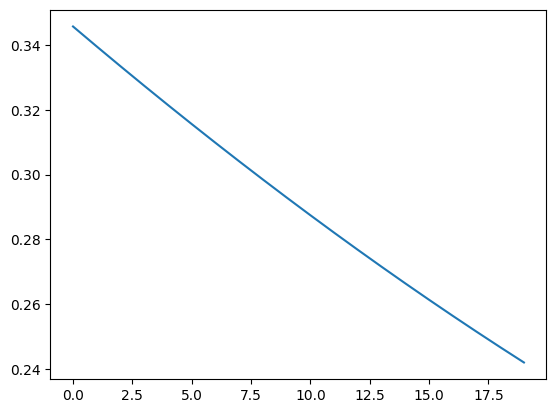

In [15]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots()
ax.plot(losses2)
plt.show()

In [16]:
# Як швидко знижується помилка?
print("Втрати (помилка) зменшуються в сердньому на {} за епоху")
(losses2[19] - losses2[0]) / 20

Втрати (помилка) зменшуються в сердньому на {} за епоху


-0.005180642753839493

In [17]:
fig.savefig("loss_healthrisk.png")